In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Load CSV file
df = pd.read_csv(r"C:\Users\USER\OneDrive\Desktop\LinearAlgo2.0\(Task) HR_comma_sep.csv")

# Display first 5 rows
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [27]:
df.left.value_counts()

left
0    11428
1     3571
Name: count, dtype: int64

In [28]:
df.left.value_counts()

left
0    11428
1     3571
Name: count, dtype: int64

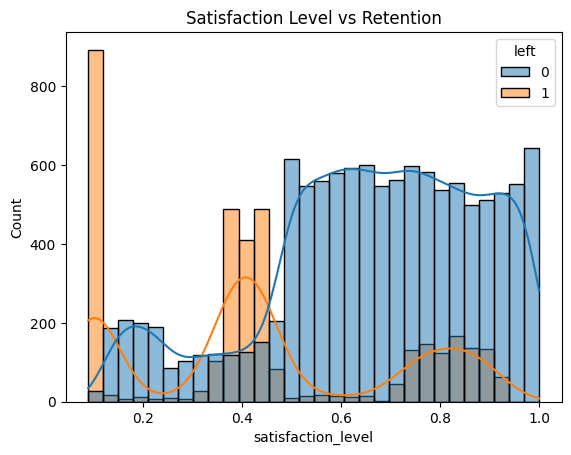

In [29]:
sns.histplot(data=df, x="satisfaction_level", hue="left", kde=True)
plt.title("Satisfaction Level vs Retention")
plt.show()

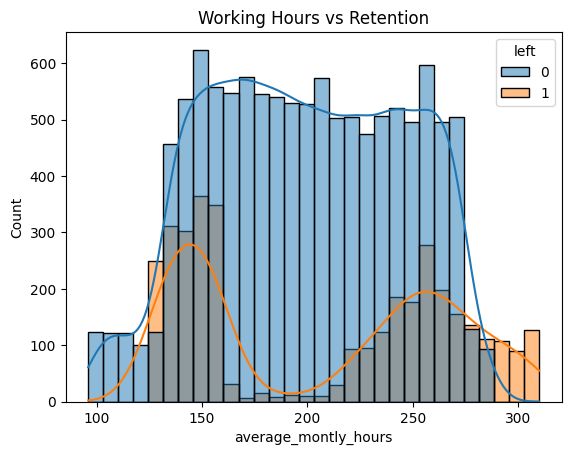

In [30]:
sns.histplot(data=df, x="average_montly_hours", hue="left", kde=True)
plt.title("Working Hours vs Retention")
plt.show()

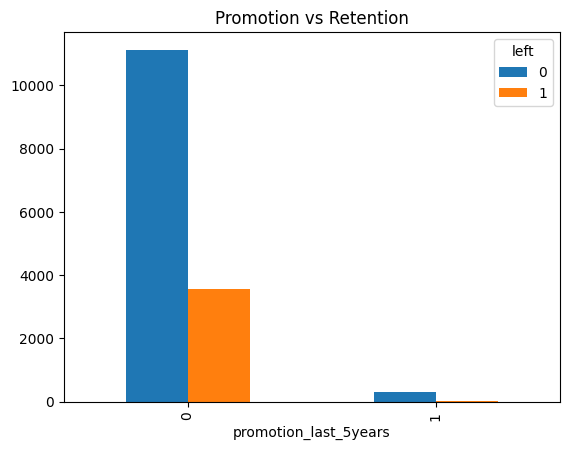

In [31]:
pd.crosstab(df.promotion_last_5years, df.left).plot(kind='bar')
plt.title("Promotion vs Retention")
plt.show()

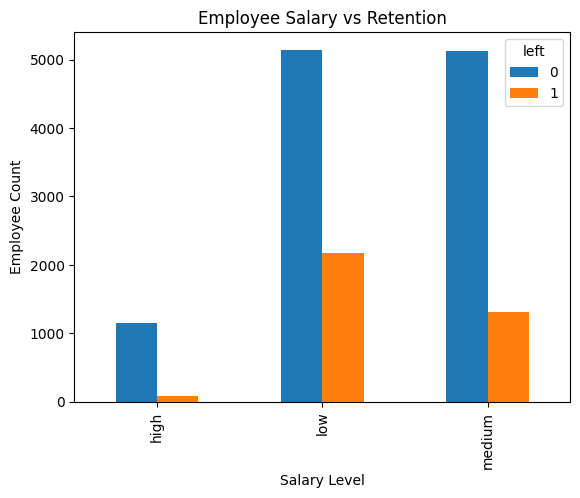

In [32]:
pd.crosstab(df.salary, df.left).plot(kind='bar')

plt.title("Employee Salary vs Retention")
plt.xlabel("Salary Level")
plt.ylabel("Employee Count")
plt.show()

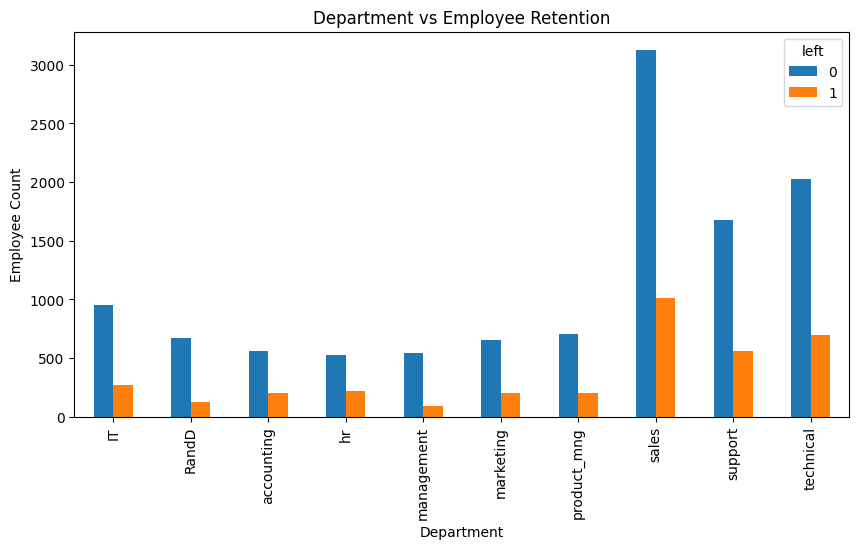

In [33]:
pd.crosstab(df.Department, df.left).plot(kind='bar', figsize=(10,5))

plt.title("Department vs Employee Retention")
plt.xlabel("Department")
plt.ylabel("Employee Count")
plt.show()

In [34]:
sub_df = df[['satisfaction_level','average_montly_hours',
             'promotion_last_5years','salary']]
sub_df.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary
0,0.38,157,0,low
1,0.80,262,0,medium
2,0.11,272,0,medium
3,0.72,223,0,low
4,0.37,159,0,low


In [35]:
salary_dummies = pd.get_dummies(sub_df.salary, prefix="salary")
df_model = pd.concat([sub_df, salary_dummies], axis=1)
df_model.drop('salary', axis=1, inplace=True)

df_model.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary_high,salary_low,salary_medium
0,0.38,157,0,False,True,False
1,0.80,262,0,False,False,True
2,0.11,272,0,False,False,True
3,0.72,223,0,False,True,False
4,0.37,159,0,False,True,False


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df_model
y = df.left

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [37]:
accuracy = model.score(X_test, y_test)
print("Model Accuracy =", accuracy)

Model Accuracy = 0.7806666666666666


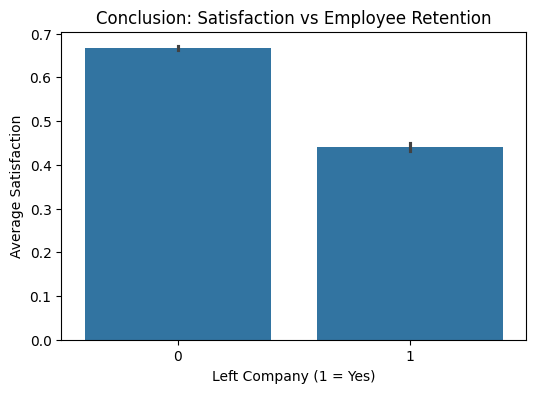

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Satisfaction Level vs Retention
plt.figure(figsize=(6,4))
sns.barplot(x=df.left, y=df.satisfaction_level)
plt.title("Conclusion: Satisfaction vs Employee Retention")
plt.xlabel("Left Company (1 = Yes)")
plt.ylabel("Average Satisfaction")
plt.show()

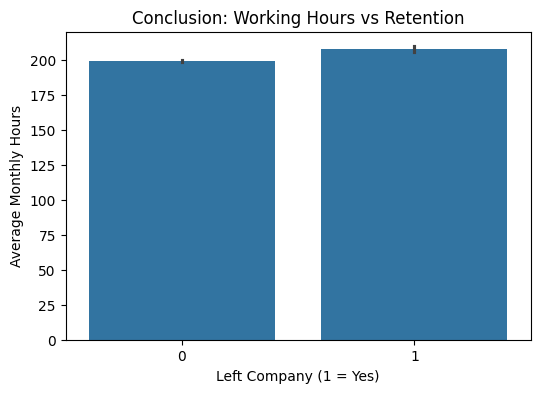

In [39]:
plt.figure(figsize=(6,4))
sns.barplot(x=df.left, y=df.average_montly_hours)
plt.title("Conclusion: Working Hours vs Retention")
plt.xlabel("Left Company (1 = Yes)")
plt.ylabel("Average Monthly Hours")
plt.show()

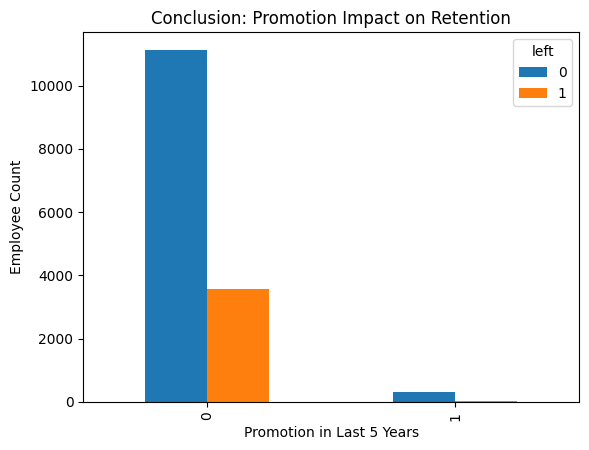

In [40]:
pd.crosstab(df.promotion_last_5years, df.left).plot(kind='bar')
plt.title("Conclusion: Promotion Impact on Retention")
plt.xlabel("Promotion in Last 5 Years")
plt.ylabel("Employee Count")
plt.show()

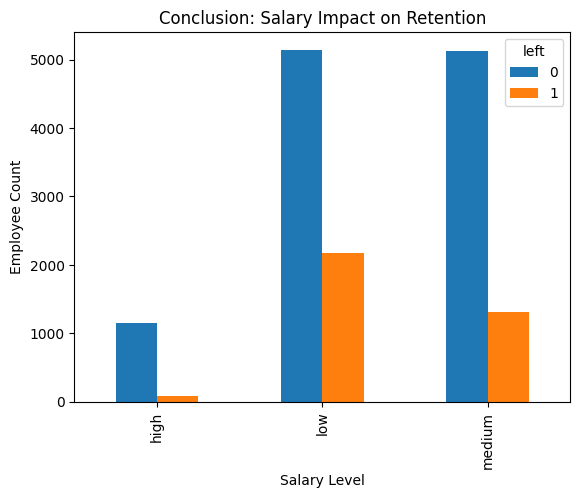

In [41]:
pd.crosstab(df.salary, df.left).plot(kind='bar')
plt.title("Conclusion: Salary Impact on Retention")
plt.xlabel("Salary Level")
plt.ylabel("Employee Count")
plt.show()

In [42]:
print("Final Model Accuracy =", model.score(X_test, y_test))

Final Model Accuracy = 0.7806666666666666
